# 05 - Results: collation across all schemes - CSE-CIC-IDS2018

In [1]:
DATASET = "cic2018"
FT_ROOT = None

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids.evaluation.cross_val import METRIC_NAMES

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "05_results.log", "nb05")

rows = []
for mp in sorted(P.runs.glob("*/*/metrics.json")):
    d = nbc.load_json(mp)
    for split in ("test", "validation"):
        if split in d:
            m = {k: v for k, v in d[split].items() if k != "name"}
            rows.append({"scheme": d["scheme"], "model": d["model"], "split": split,
                         "n_train": d["n_train"], "fit_seconds": d["fit_seconds"], **m})
summary = pd.DataFrame(rows)
summary.to_csv(P.results / "summary_all_schemes.csv", index=False)
log.info("collected %d (scheme, model, split) results", len(summary))
summary.head(10)

2026-07-06 10:30:37,980 INFO nb05: collected 25 (scheme, model, split) results


,scheme,model,split,n_train,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,detection_time_ms,n_test
0,70_20_10,decision_tree,test,1110830,18.622,0.730445,0.647658,0.769439,0.667148,0.918132,0.000274,158691
1,70_20_10,decision_tree,validation,1110830,18.622,0.731181,0.645166,0.761722,0.664380,0.918934,0.000253,317381
2,70_20_10,knn,test,1110830,4.369,0.722354,0.629854,0.783743,0.644898,0.928521,0.458286,158691
3,70_20_10,knn,validation,1110830,4.369,0.721171,0.624108,0.824969,0.643550,0.927888,0.445265,317381
4,70_20_10,naive_bayes,test,1110830,4.444,0.492013,0.432572,0.669075,0.446706,0.860258,0.000705,158691
5,70_20_10,naive_bayes,validation,1110830,4.444,0.493426,0.434913,0.727896,0.448563,0.860863,0.000674,317381
6,70_20_10,random_forest,test,1110830,35.663,0.753464,0.651479,0.786728,0.662526,0.950006,0.005449,158691
7,70_20_10,random_forest,validation,1110830,35.663,0.752424,0.675473,0.826181,0.694351,0.949789,0.005408,317381
8,70_20_10,svm,test,1110830,11.086,0.471363,0.461550,0.720002,0.492692,0.874656,0.001019,158691
9,70_20_10,svm,validation,1110830,11.086,0.471065,0.461256,0.793430,0.496180,0.874571,0.000420,317381


## 1. Test-set comparison: model x scheme, one table per metric

In [3]:
test = summary[summary["split"] == "test"]
pivots = {}
for metric in METRIC_NAMES + ["detection_time_ms", "fit_seconds"]:
    pv = test.pivot_table(index="model", columns="scheme", values=metric).round(4)
    pv.to_csv(P.results / f"pivot_{metric}.csv")
    pivots[metric] = pv
log.info("saved %d pivot tables to %s", len(pivots), P.results)
pivots["f1_macro"]

2026-07-06 10:30:38,024 INFO nb05: saved 7 pivot tables to /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2018/results


scheme,70_20_10,70_30,80_20,90_10
model,,,,
decision_tree,0.6671,0.6684,0.6536,0.6674
knn,0.6449,0.6471,0.6547,0.6433
naive_bayes,0.4467,0.4384,0.4514,0.4080
random_forest,0.6625,0.6912,0.6838,0.6924
svm,0.4927,0.4901,0.5150,0.5028


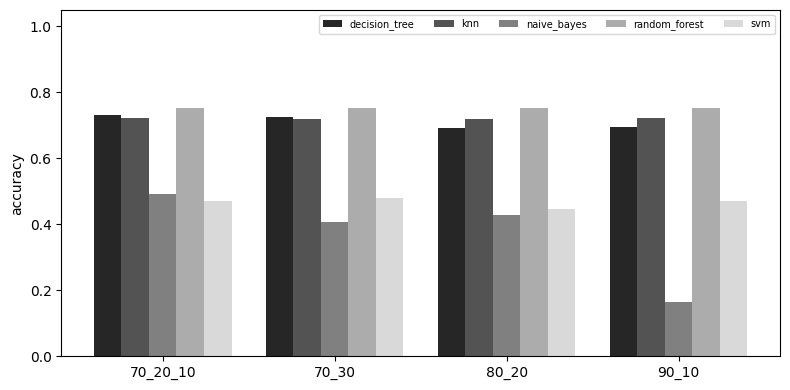

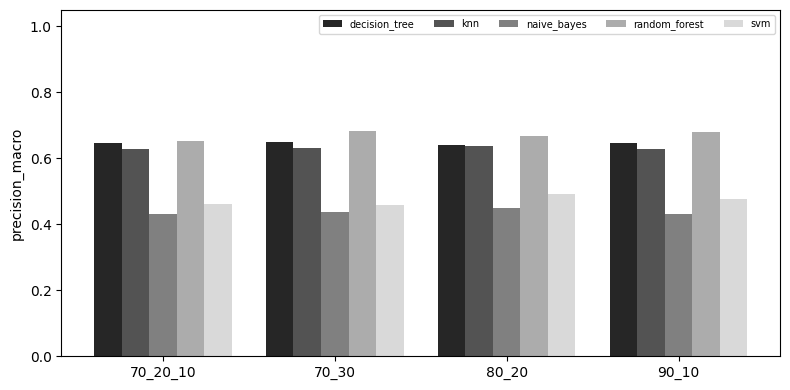

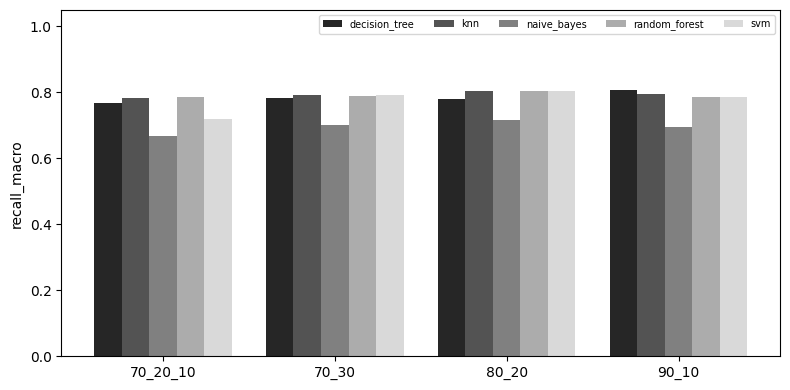

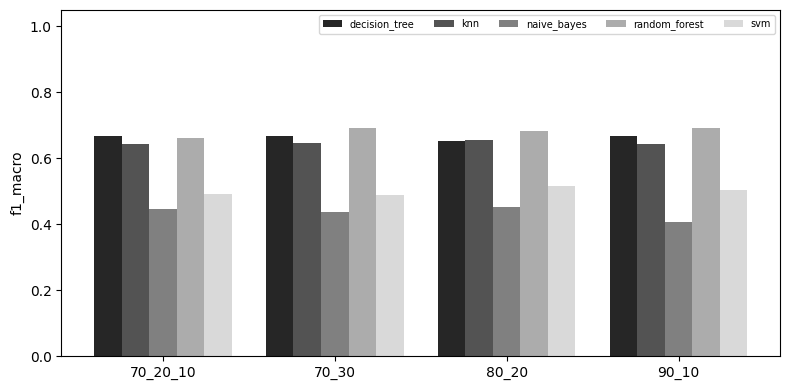

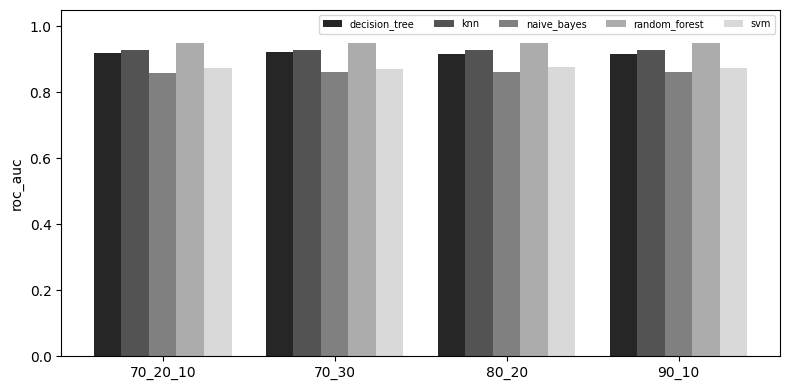

In [4]:
for metric in METRIC_NAMES:
    pv = pivots[metric]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pv.columns))
    width = 0.8 / len(pv.index)
    for i, model in enumerate(pv.index):
        ax.bar(x + i * width, pv.loc[model], width,
               label=model, color=str(0.15 + 0.7 * i / max(1, len(pv.index) - 1)))
    ax.set_xticks(x + 0.4 - width / 2)
    ax.set_xticklabels(pv.columns)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, ncol=len(pv.index))
    fig.tight_layout()
    fig.savefig(P.results / "plots" / f"{metric}_by_scheme.png", dpi=150)
    plt.show()

## 2. Cross-validation (cv5): mean ± std per model

In [5]:
cv_summary_path = P.runs / "cv5" / "cv_summary.csv"
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    cv_summary.to_csv(P.results / "cv5_summary.csv", index=False)
    display(cv_summary.round(4))
else:
    log.warning("no cv5 results found at %s", cv_summary_path)

,model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,decision_tree,0.7189,0.0115,0.6550,0.0161,0.7967,0.0288,0.6677,0.0092,0.9166,0.0031
1,knn,0.7187,0.0017,0.6230,0.0144,0.8161,0.0287,0.6402,0.0150,0.9269,0.0007
2,naive_bayes,0.3059,0.1156,0.4182,0.0178,0.6685,0.0328,0.4146,0.0203,0.8656,0.0021
3,random_forest,0.7411,0.0014,0.6452,0.0227,0.8011,0.0341,0.6580,0.0264,0.9503,0.0003
4,svm,0.4777,0.0061,0.4362,0.0042,0.7699,0.0242,0.4671,0.0068,0.8683,0.0158


## 3. Validation vs test on the 70/20/10 scheme

In [6]:
vt = summary[summary["scheme"] == "70_20_10"].pivot_table(
    index="model", columns="split",
    values=[m for m in METRIC_NAMES if m in summary.columns]).round(4)
vt.to_csv(P.results / "val_vs_test_70_20_10.csv")
vt

accuracy            f1_macro            precision_macro  \
split             test validation     test validation            test   
model                                                                   
decision_tree   0.7304     0.7312   0.6671     0.6644          0.6477   
knn             0.7224     0.7212   0.6449     0.6436          0.6299   
naive_bayes     0.4920     0.4934   0.4467     0.4486          0.4326   
random_forest   0.7535     0.7524   0.6625     0.6944          0.6515   
svm             0.4714     0.4711   0.4927     0.4962          0.4615   

                         recall_macro            roc_auc             
split         validation         test validation    test validation  
model                                                                
decision_tree     0.6452       0.7694     0.7617  0.9181     0.9189  
knn               0.6241       0.7837     0.8250  0.9285     0.9279  
naive_bayes       0.4349       0.6691     0.7279  0.8603     0.8609  
random_forest     0.6755       0.7867     0.8262  0.9500     0.9498  
svm               0.4613       0.7200     0.7934  0.8747     0.8746

## 4. Artifact inventory

In [7]:
inventory = sorted(str(p.relative_to(P.root)) for p in P.root.rglob("*") if p.is_file())
nbc.save_json(inventory, P.results / "artifact_inventory.json")
log.info("study produced %d artifact files under %s", len(inventory), P.root)
print(f"{len(inventory)} files; key results:")
for f in inventory:
    if f.startswith("results/") and f.endswith(".csv"):
        print(" ", f)

2026-07-06 10:30:38,620 INFO nb05: study produced 184 artifact files under /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2018
184 files; key results:
  results/cv5_summary.csv
  results/pivot_accuracy.csv
  results/pivot_detection_time_ms.csv
  results/pivot_f1_macro.csv
  results/pivot_fit_seconds.csv
  results/pivot_precision_macro.csv
  results/pivot_recall_macro.csv
  results/pivot_roc_auc.csv
  results/summary_all_schemes.csv
  results/val_vs_test_70_20_10.csv
